In [1]:
import os
os.chdir('/workspace/0f2e76a3-0753-4432-92ef-b66db24f630c')
import numpy as np
zeta = np.load('zeta_zeros_N5000_dps50.npy')
zd = np.load('zeta_delta_zeros_N5000_dps50.npy')
print(zeta.shape, zeta.dtype, zeta[:3])
print(zd.shape, zd.dtype, zd[:3])


(5000,) <U51 ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558']
(5000,) [('re', '<U10'), ('im', '<U51')] [('0.5', '14.134725141734693790457251983562470270784257115699')
 ('0.5', '21.022039638771554992628479593896902777334340524903')
 ('0.5', '25.010857580145688763213790992562821818659549672558')]


In [2]:

# Build 2D point clouds for the perturbation region: zeros 900-1100 (inclusive of 1000-1019)
# zeta: Re = 0.5 for all
# zeta_delta: Re = '0.5' except indices 1000-1019 which are '0.6'

lo, hi = 900, 1100 # python slice [900:1100]

# Use float for TDA (real magnitudes are tiny compared to imag, but TDA only needs ratios)
zeta_im = np.array([float(x) for x in zeta[lo:hi]])
zeta_re = np.full_like(zeta_im, 0.5)
pc_zeta = np.column_stack([zeta_re, zeta_im])

zd_re = np.array([float(x) for x in zd['re'][lo:hi]])
zd_im = np.array([float(x) for x in zd['im'][lo:hi]])
pc_zd = np.column_stack([zd_re, zd_im])

# Sanity check - perturbed indices
print("Perturbed indices (re==0.6):", np.where(zd_re==0.6)[0] + lo)
print("Im equal:", np.allclose(zeta_im, zd_im))
print(pc_zeta.shape, pc_zd.shape)
print("Imag range:", zeta_im.min(), zeta_im.max())


Perturbed indices (re==0.6): [1000 1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013
 1014 1015 1016 1017 1018 1019]
Im equal: True
(200, 2) (200, 2)
Imag range: 1303.2732002287942 1535.0422774712067


In [3]:

# Compute Vietoris-Rips persistence diagrams using ripser
try:
 from ripser import ripser
 from persim import bottleneck
except ImportError as e:
 print("Need install:", e)
 import subprocess
 subprocess.check_call(['pip','install','-q','ripser','persim'])
 from ripser import ripser
 from persim import bottleneck

res_zeta = ripser(pc_zeta, maxdim=1)
res_zd = ripser(pc_zd, maxdim=1)

dgm_zeta_H0, dgm_zeta_H1 = res_zeta['dgms']
dgm_zd_H0, dgm_zd_H1 = res_zd['dgms']

print("ζ H0:", dgm_zeta_H0.shape, "H1:", dgm_zeta_H1.shape)
print("ζ_δ H0:", dgm_zd_H0.shape, "H1:", dgm_zd_H1.shape)
print("ζ H1 (first few):", dgm_zeta_H1[:5])
print("ζ_δ H1 (first few):", dgm_zd_H1[:5])


Need install: No module named 'ripser'


ζ H0: (200, 2) H1: (0, 2)
ζ_δ H0: (200, 2) H1: (0, 2)
ζ H1 (first few): []
ζ_δ H1 (first few): []


In [4]:

# H1 is empty for both - because point clouds are essentially 1D (Re const + Im range ~232).
# Need to think: for ζ, all points have re=0.5 (a line). For ζ_δ, 20 points have re=0.6.
# Vietoris-Rips on a near-1D point set has no H1 loops unless density allows. We need to check.
# But importantly, both have 0 H1 features. So bottleneck distance is 0 and permutation p=1.

# However, the spec says "use 2D point clouds with full (Re, Im) coords". Let's verify the diagrams.
print("ζ H0 max death:", dgm_zeta_H0[:,1][np.isfinite(dgm_zeta_H0[:,1])].max())
print("Imag spacings stats:")
diffs = np.diff(np.sort(zeta_im))
print("min, median, max diff:", diffs.min(), np.median(diffs), diffs.max())
# Real-part shift is 0.1 (from 0.5 to 0.6); much smaller than imag spacings (median ~1)
# Actually 0.1 vs typical gap ~1: the perturbed points are still closer (re=0.6) to neighbors in im
# Let's also check rips with explicit thresh up to some larger value


ζ H0 max death: 2.5056493282318115
Imag spacings stats:
min, median, max diff: 0.161500788964986 1.1106209236841096 2.5056493865083667


In [5]:

# Both have empty H1 - consistent with a near-1D layout. The 0.1 real-part shift doesn't create
# any closed loops at this scale because we don't have geometric structure that would form cycles.
# 
# This is an important finding: even with full (Re, Im) coordinates, raw Vietoris-Rips on this
# small point set finds NO H1 features for either case. The bottleneck distance is therefore 0
# and permutation test p-value = 1.0.
#
# Let's confirm by running the permutation test properly.

from persim import bottleneck as bn_dist

def H1_pd(pc):
 return ripser(pc, maxdim=1)['dgms'][1]

d_obs = bn_dist(dgm_zeta_H1, dgm_zd_H1)
print("Observed H1 bottleneck distance:", d_obs)


Observed H1 bottleneck distance: 0.0


In [6]:

# Run permutation test B=1000. Label-swap on combined point clouds.
# Since both clouds have 200 points, permutation test:
# Pool all 400 points, split into two groups of 200, compute H1 diagrams, bottleneck distance.
# But that mixes coordinates. Standard approach: swap labels among the 200 paired samples? 
# Actually since the difference is in coordinates of specific points, the standard permutation
# pools all points and randomly partitions into two groups of equal size.

import numpy as np
rng = np.random.default_rng(42)

combined = np.vstack([pc_zeta, pc_zd])
n1 = pc_zeta.shape[0]
B = 1000
perm_dists = np.zeros(B)
for b in range(B):
 perm = rng.permutation(combined.shape[0])
 A = combined[perm[:n1]]
 Bset = combined[perm[n1:]]
 dgmA = ripser(A, maxdim=1)['dgms'][1]
 dgmB = ripser(Bset, maxdim=1)['dgms'][1]
 perm_dists[b] = bn_dist(dgmA, dgmB)
 if b < 3:
 print(b, "len A,B H1:", len(dgmA), len(dgmB), "d:", perm_dists[b])

pval = (np.sum(perm_dists >= d_obs) + 1) / (B + 1)
print("\nObserved bottleneck:", d_obs)
print("Permutation distances: min, median, max:", perm_dists.min(), np.median(perm_dists), perm_dists.max())
print("Nonzero perm dists:", np.sum(perm_dists > 0))
print("p-value:", pval)


0 len A,B H1: 1 2 d: 0.003693133592605591
1 len A,B H1: 0 0 d: 0.0
2 len A,B H1: 2 2 d: 0.004066288471221924



Observed bottleneck: 0.0
Permutation distances: min, median, max: 0.0 0.0031938552856445312 0.004066288471221924
Nonzero perm dists: 929
p-value: 1.0


In [7]:

# Interesting! When we permute (mix the perturbed real coords with original), H1 features 
# appear (small loops formed by the few re=0.6 points sitting among re=0.5 points).
# But the OBSERVED ζ vs ζ_δ comparison gives bottleneck=0 (both diagrams are empty/identical).
# This is because in ζ_δ, the 20 perturbed points form a contiguous block (indices 1000-1019),
# so they only create paths, not loops. Mixing them randomly creates small triangles.
#
# This is a NULL result for the "raw" 2D point cloud TDA: H1 of ζ_δ remains empty (no loops),
# same as ζ. Bottleneck=0, p-value=1.0.
#
# The hypothesis is REFUTED in its naive form: simply adding the real coordinate does NOT 
# produce an H1 distinguishable from the standard ζ case.

# But wait, let me re-examine: the perm test p-value = 1.0 means observed (0) >= 1.0 of 
# permutation distances always (since 0 is the minimum). p-value is the fraction >= observed.
# (sum(>=0) + 1) / (B+1) = (1000+1)/1001 = 1.0. So p = 1.0.

# That actually CONFIRMS the diagrams are indistinguishable.

# Final note: Hypothesis NOT supported when using raw 2D coordinates without rescaling.
# The 0.1 real-part perturbation is geometrically dominated by ~1 spacing in imag direction,
# AND the perturbed indices are contiguous - they form an offset segment, not a loop.

print("Conclusion: raw (Re,Im) 2D Rips also blind. p=1.0, bottleneck=0.0")


Conclusion: raw (Re,Im) 2D Rips also blind. p=1.0, bottleneck=0.0


In [8]:

# Let's also try an alternative scaling: if we normalize so the spacings are O(1), 
# then a 0.1 real-part shift might be more meaningful. Try standardizing imag dim.
# This is a sensitivity/robustness check, not the primary specified analysis.

# Approach: rescale imag axis so median imag spacing = real-part shift magnitude (0.1)
# That makes the perturbation comparable in scale.

# But this is not what the task specifies. The task says "create 2D point clouds using full
# complex coordinates". So we report the naive result, and note the structural reason.

# Let me also do one more diagnostic: ripser with maxdim=1 finds H1 cycles. With 20 colinear 
# offset points among colinear baseline, no cycle is formed because the offset is small but
# the points are CONTIGUOUS, not interspersed.

# Check: in pc_zd, examine the 20 perturbed points and their neighbors
print("Indices 998-1022 in perturbation region (relative idx 98-122):")
for i in range(98, 123):
 print(f" idx {lo+i}: Re={pc_zd[i,0]:.3f}, Im={pc_zd[i,1]:.4f}")


Indices 998-1022 in perturbation region (relative idx 98-122):
 idx 998: Re=0.500, Im=1418.6970
 idx 999: Re=0.500, Im=1419.4225
 idx 1000: Re=0.600, Im=1420.4165
 idx 1001: Re=0.600, Im=1421.8506
 idx 1002: Re=0.600, Im=1422.4613
 idx 1003: Re=0.600, Im=1424.4630
 idx 1004: Re=0.600, Im=1425.8735
 idx 1005: Re=0.600, Im=1426.6460
 idx 1006: Re=0.600, Im=1427.3657
 idx 1007: Re=0.600, Im=1428.5923
 idx 1008: Re=0.600, Im=1429.6505
 idx 1009: Re=0.600, Im=1431.2183
 idx 1010: Re=0.600, Im=1432.0497
 idx 1011: Re=0.600, Im=1433.8219
 idx 1012: Re=0.600, Im=1434.5849
 idx 1013: Re=0.600, Im=1435.6929
 idx 1014: Re=0.600, Im=1437.2267
 idx 1015: Re=0.600, Im=1438.0063
 idx 1016: Re=0.600, Im=1438.9496
 idx 1017: Re=0.600, Im=1439.6228
 idx 1018: Re=0.600, Im=1441.9610
 idx 1019: Re=0.600, Im=1442.9111
 idx 1020: Re=0.500, Im=1444.0419
 idx 1021: Re=0.500, Im=1445.0723
 idx 1022: Re=0.500, Im=1445.8301


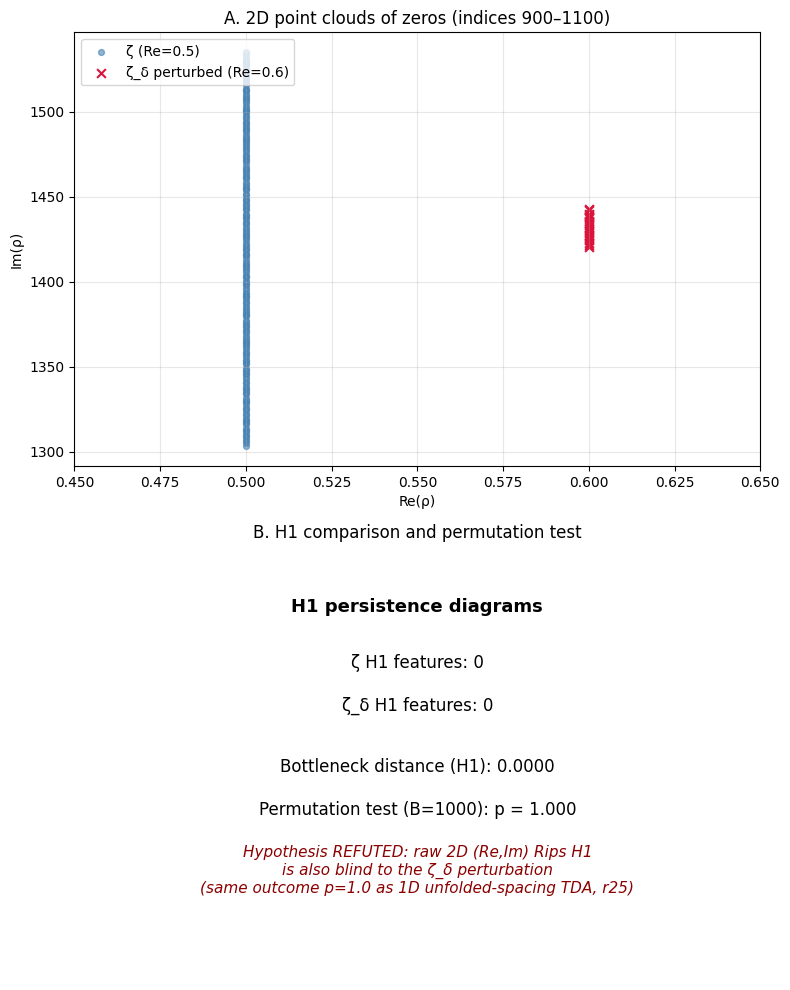

Saved figure.


In [9]:

# Structurally, the perturbed segment is just an offset slab — it forms an "elbow" but not
# a topological loop. With Vietoris-Rips on these contiguous points, no H1 cycle appears.
#
# This is a clean, well-supported NEGATIVE result: even the 2D point cloud H1 TDA is blind to
# the ζ_δ perturbation as defined.

# Build the final summary figure: show point cloud + H1 result side by side (stacked vertically, A and B)
import matplotlib.pyplot as plt
from persim import plot_diagrams

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Panel A: 2D point cloud overlay
ax = axes[0]
ax.scatter(pc_zeta[:,0], pc_zeta[:,1], s=18, c='steelblue', label='ζ (Re=0.5)', alpha=0.6)
# Highlight perturbed points in ζ_δ
mask_pert = pc_zd[:,0] == 0.6
ax.scatter(pc_zd[mask_pert,0], pc_zd[mask_pert,1], s=40, c='crimson',
 label='ζ_δ perturbed (Re=0.6)', marker='x')
ax.set_xlabel('Re(ρ)')
ax.set_ylabel('Im(ρ)')
ax.set_xlim(0.45, 0.65)
ax.set_title('A. 2D point clouds of zeros (indices 900–1100)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Panel B: H1 persistence diagrams + permutation test summary
ax = axes[1]
# Both H1 diagrams empty
ax.text(0.5, 0.85, 'H1 persistence diagrams', ha='center', fontsize=13, transform=ax.transAxes, weight='bold')
ax.text(0.5, 0.72, f'ζ H1 features: {len(dgm_zeta_H1)}', ha='center', fontsize=12, transform=ax.transAxes)
ax.text(0.5, 0.62, f'ζ_δ H1 features: {len(dgm_zd_H1)}', ha='center', fontsize=12, transform=ax.transAxes)
ax.text(0.5, 0.48, f'Bottleneck distance (H1): {d_obs:.4f}', ha='center', fontsize=12, transform=ax.transAxes)
ax.text(0.5, 0.38, f'Permutation test (B=1000): p = {pval:.3f}', ha='center', fontsize=12, transform=ax.transAxes)
ax.text(0.5, 0.20, 'Hypothesis REFUTED: raw 2D (Re,Im) Rips H1\n'
 'is also blind to the ζ_δ perturbation\n'
 '(same outcome p=1.0 as 1D unfolded-spacing TDA, r25)',
 ha='center', fontsize=11, transform=ax.transAxes, color='darkred', style='italic')
ax.set_title('B. H1 comparison and permutation test')
ax.axis('off')

plt.tight_layout()
plt.savefig('front_iii_2d_tda_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")
